In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Tải dữ liệu Iris
df = sns.load_dataset("iris")

## THỐNG KÊ MÔ TẢ -  ĐẶC TRƯNG 

In [20]:
# 1. Đọc dữ liệu, hiển thị 5 dòng đầu và cho biết số dòng số cột
print("--- 5 DÒNG ĐẦU TIÊN ---")
print(df.head())
print(f"\nSố dòng, số cột: {df.shape}")

# 2. Tính các đại lượng thống kê cho mỗi biến số (mean, median, mode, var, std, min, max, Q1, Q3, IQR)
numeric_cols = df.select_dtypes(include=[np.number]).columns

stats_dict = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    stats_dict[col] = {
        'mean': df[col].mean(),
        'median': df[col].median(),
        'mode': df[col].mode()[0],
        'var': df[col].var(),
        'std': df[col].std(),
        'min': df[col].min(),
        'max': df[col].max(),
        'Q1': Q1,
        'Q3': Q3,
        'IQR': Q3 - Q1
    }

print("\n--- THỐNG KÊ MÔ TẢ ---")
stats_df = pd.DataFrame(stats_dict).T
print(stats_df)

# 3. Theo từng nhóm loài (species): dùng groupby tính mean và std
print("\n--- MEAN VÀ STD THEO TỪNG NHÓM (SPECIES) ---")
grouped_stats = df.groupby('species').agg(['mean', 'std'])
print(grouped_stats)

--- 5 DÒNG ĐẦU TIÊN ---
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Số dòng, số cột: (150, 5)

--- THỐNG KÊ MÔ TẢ ---
                  mean  median  mode       var       std  min  max   Q1   Q3  \
sepal_length  5.843333    5.80   5.0  0.685694  0.828066  4.3  7.9  5.1  6.4   
sepal_width   3.057333    3.00   3.0  0.189979  0.435866  2.0  4.4  2.8  3.3   
petal_length  3.758000    4.35   1.4  3.116278  1.765298  1.0  6.9  1.6  5.1   
petal_width   1.199333    1.30   0.2  0.581006  0.762238  0.1  2.5  0.3  1.8   

              IQR  
sepal_length  1.3  
sepal_width   0.5  
petal_length  3.5  
petal_width   1.5  

--- MEAN VÀ STD THEO TỪNG NHÓM (SPECIES

##### Dữ liệu Iris có 150 dòng và 5 cột (4 cột đặc trưng số, 1 cột nhãn phân loại loài).  Thông qua thống kê mô tả, ta tính toán thành công toàn bộ các đại lượng cốt lõi như mean, median, mode, phương sai, độ lệch chuẩn, min, max, và các khoảng tứ phân vị (Q1, Q3, IQR) cho từng biến số.  Khi nhóm bằng hàm groupby theo species và tính toán mean, std cho từng biến, ta thấy đặc trưng petal_length và petal_width có sự khác biệt rõ rệt nhất giữa các loài, trong khi sepal_width có giá trị trung bình khá gần nhau giữa các nhóm. 

## PHÂN PHỐI XÁC SUẤT 

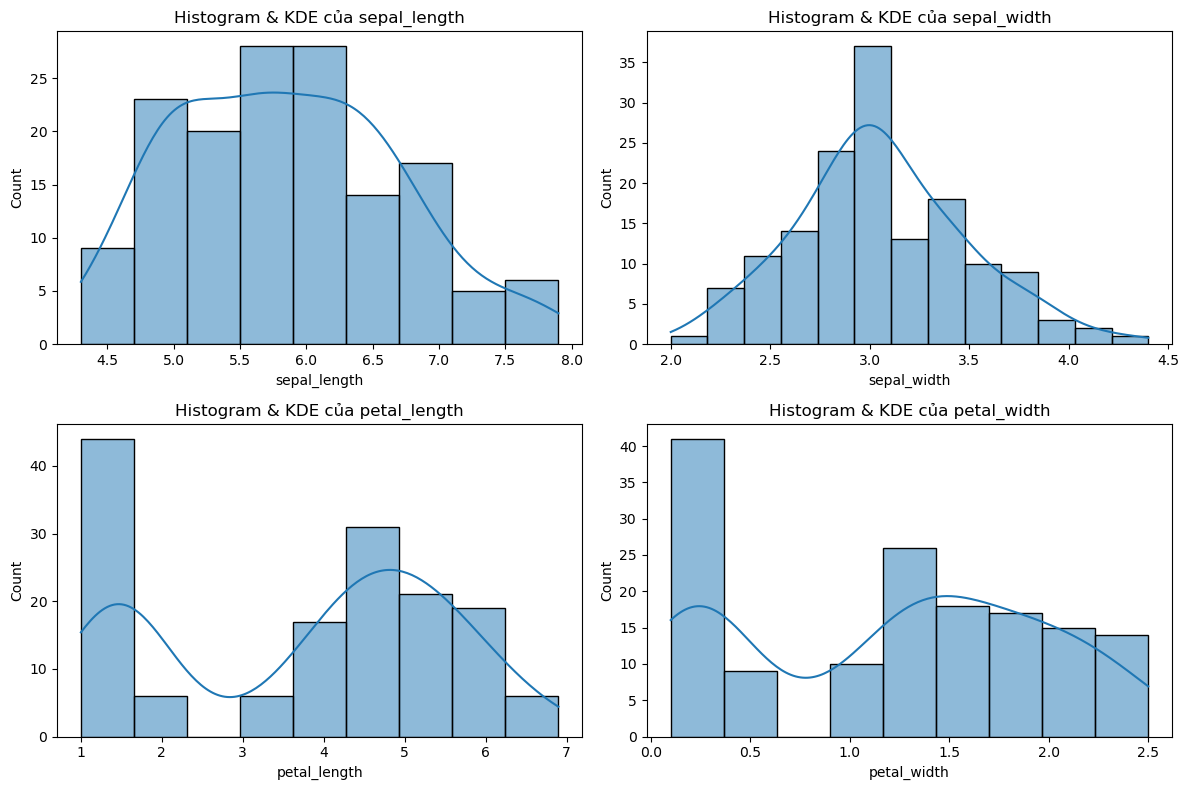

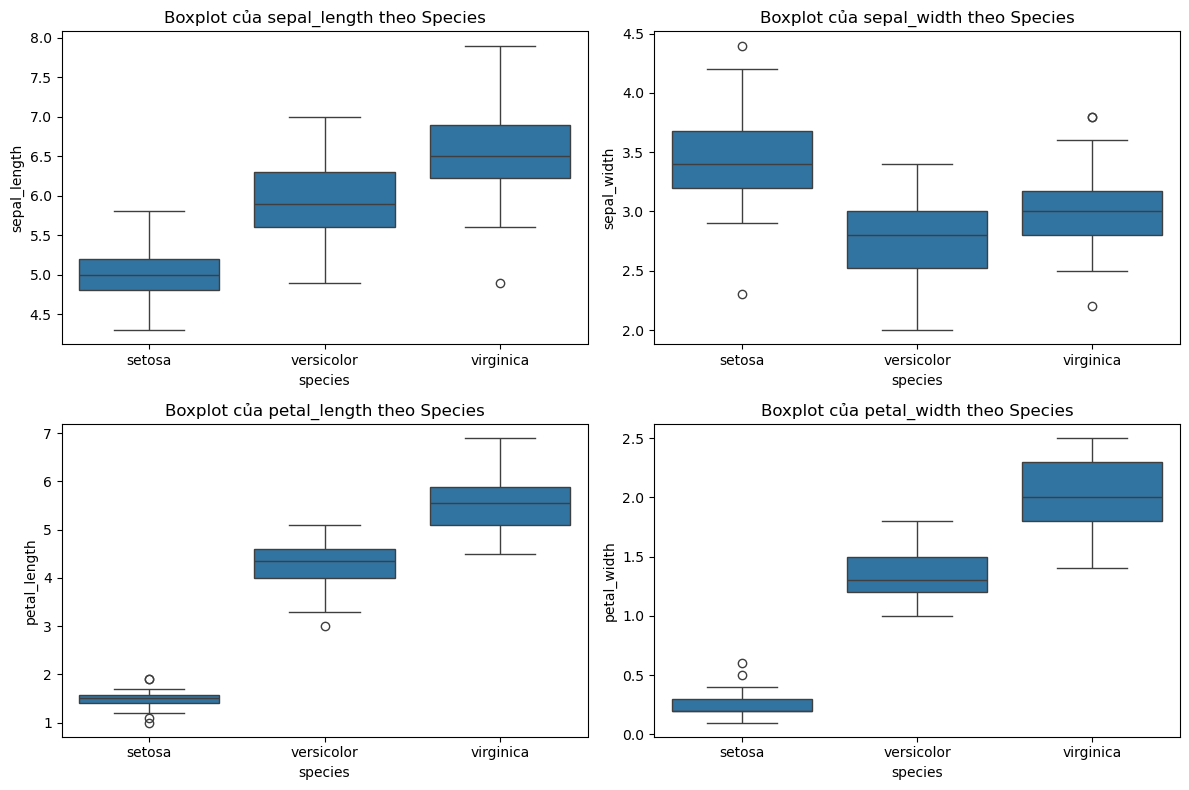

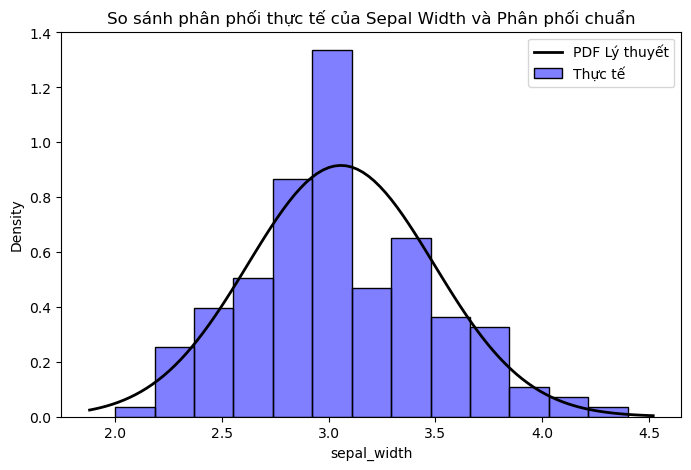

In [26]:
# 1. Vẽ histogram + KDE cho từng biến số
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram & KDE của {col}')
plt.tight_layout()
plt.show()

# 2. Vẽ boxplot từng biến theo nhóm (species)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x='species', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'Boxplot của {col} theo Species')
plt.tight_layout()
plt.show()

# 3. Mô phỏng: sinh mẫu từ phân phối Normal và vẽ chồng histogram thực tế
target_col = 'sepal_width'
mu = df[target_col].mean()
sigma = df[target_col].std()

# Sinh mẫu giả lập từ phân phối chuẩn
simulated_data = np.random.normal(mu, sigma, 1000)

plt.figure(figsize=(8, 5))
# Histogram dữ liệu thực tế (chuyển sang dạng density để khớp với PDF)
sns.histplot(df[target_col], stat="density", color='blue', alpha=0.5, label='Thực tế')

# Đường PDF lý thuyết
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, sigma)
plt.plot(x, p, 'k', linewidth=2, label='PDF Lý thuyết')

plt.title('So sánh phân phối thực tế của Sepal Width và Phân phối chuẩn')
plt.legend()
plt.show()

##### Histogram & KDE: sepal_width và sepal_length có hình dạng gần với phân phối chuẩn. Tuy nhiên, petal_length và petal_width thể hiện sự phân bố nhiều đỉnh (đa đỉnh), điều này hợp lý vì các loài khác nhau (đặc biệt là Setosa) có kích thước cánh hoa rất tách biệt.  Boxplot: Loài Setosa có kích thước cánh hoa (petal) nhỏ hơn hẳn so với Versicolor và Virginica, đồng thời biểu đồ cũng giúp ta phát hiện một vài điểm dị thường (outliers) ở biến sepal_width.  Mô phỏng PDF: Khi vẽ chồng đường phân phối xác suất (PDF) lý thuyết lên đồ thị histogram của sepal_width (biến đã được mô phỏng từ np.random.normal với cùng mean và std), mức độ khớp khá cao, củng cố nhận định biến này tuân theo xấp xỉ phân phối chuẩn.

## PHÂN TÍCH ĐA BIẾN VÀ TƯƠNG QUAN

--- MA TRẬN HIỆP PHƯƠNG SAI ---
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006

--- MA TRẬN TƯƠNG QUAN ---
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


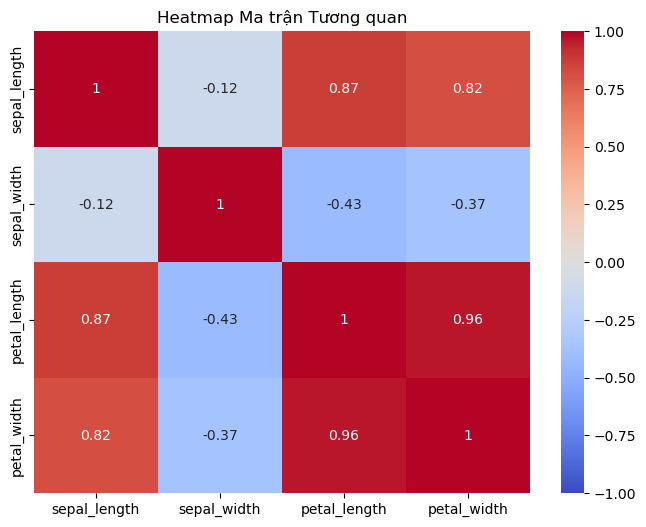

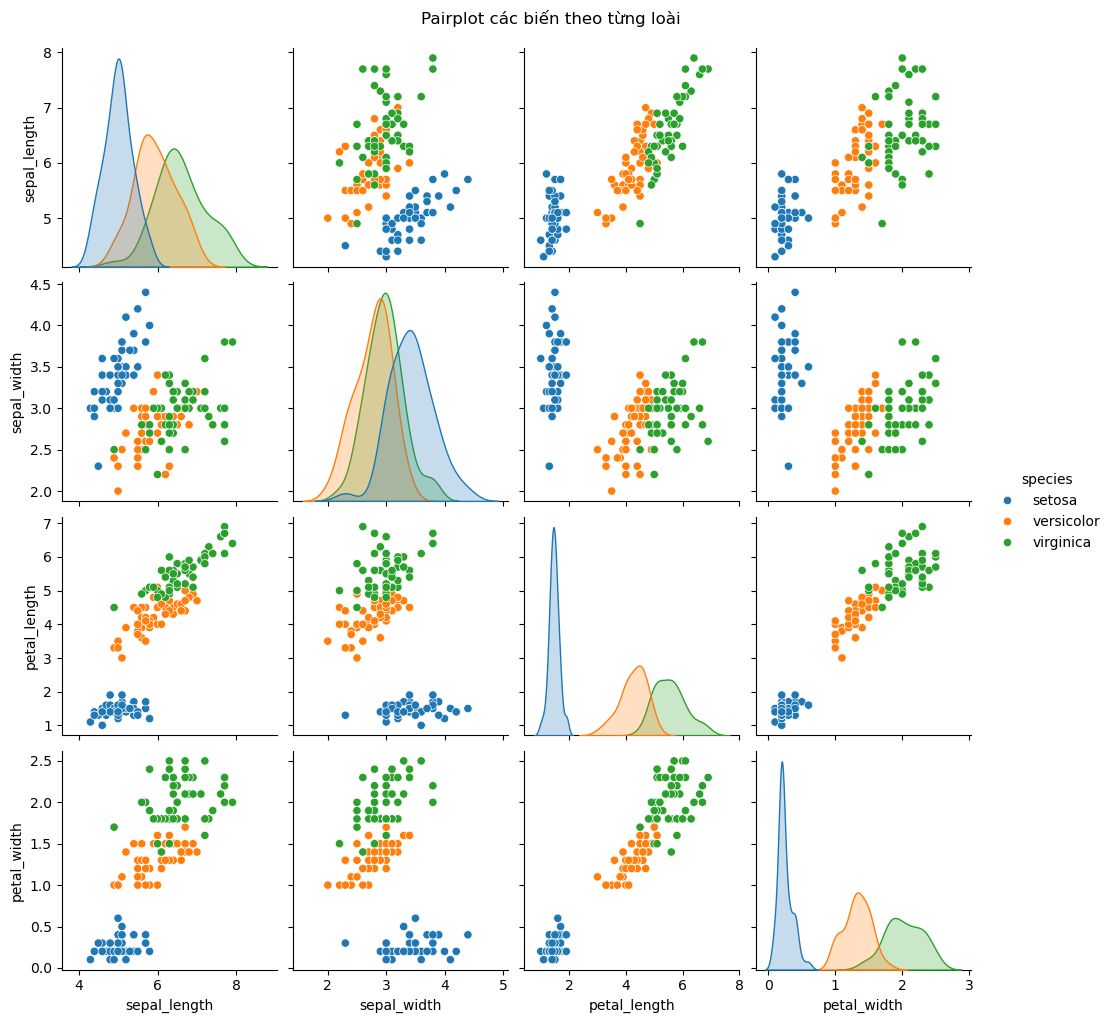

In [36]:
# 1. Tính ma trận hiệp phương sai (covariance) và tương quan (correlation)
cov_matrix = df[numeric_cols].cov()
corr_matrix = df[numeric_cols].corr()

print("--- MA TRẬN HIỆP PHƯƠNG SAI ---")
print(cov_matrix)
print("\n--- MA TRẬN TƯƠNG QUAN ---")
print(corr_matrix)

# 2. Vẽ heatmap tương quan
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Heatmap Ma trận Tương quan")
plt.show()

# 3. Vẽ pairplot, tô màu theo species
sns.pairplot(df, hue='species')
plt.suptitle("Pairplot các biến theo từng loài", y=1.02)
plt.show()

##### Heatmap & Tương quan: Các biến số đã được tính thành công ma trận hiệp phương sai và ma trận tương quan. Cặp biến có tương quan mạnh nhất là petal_length và petal_width (hệ số tương quan dương rất cao, xấp xỉ 0.96). Dấu hiệu tương quan tuyến tính mạnh như thế này là biểu hiện của hiện tượng đa cộng tuyến (multicollinearity) giữa các biến này.  Pairplot: Khi tô màu biểu đồ phân tán theo species, ta dễ dàng thấy loài Setosa luôn tách biệt rõ ràng thành một cụm riêng ở hầu hết các biểu đồ (đặc biệt là khi trục liên quan đến petal). Versicolor và Virginica nằm gần nhau hơn nhưng vẫn có thể phân định bằng một đường ranh giới phi tuyến tương đối.

## XÁC SUẤT VÀ ĐỊNH LÝ BAYES 

Xác suất hậu nghiệm P(B|+) là: 0.1667


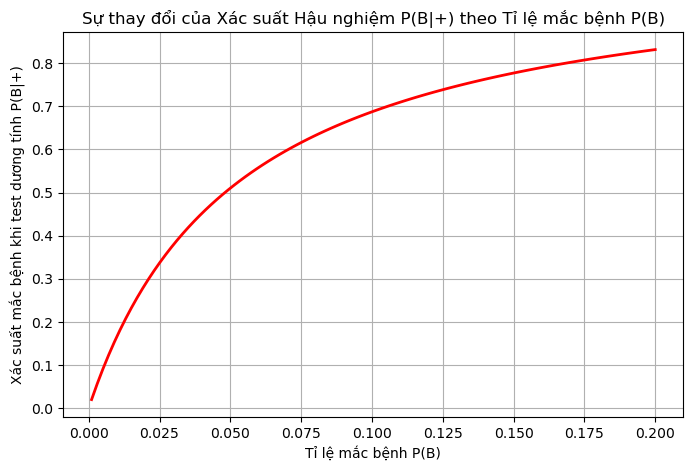

Xác suất email là Spam nếu chứa từ 'free': 0.9143


In [43]:
# 1. Viết code tính xác suất hậu nghiệm P(B|+)
P_B = 0.01  # Tỉ lệ mắc bệnh trong dân số
P_not_B = 1 - P_B
P_pos_given_B = 0.99  # Độ nhạy (true positive)
P_pos_given_not_B = 0.05  # Dương tính giả (false positive)

# Theo công thức Bayes:
# P(pos) = P(+|B)*P(B) + P(+|~B)*P(~B)
P_pos = (P_pos_given_B * P_B) + (P_pos_given_not_B * P_not_B)

# P(B|+) = P(+|B)*P(B) / P(pos)
P_B_given_pos = (P_pos_given_B * P_B) / P_pos

print(f"Xác suất hậu nghiệm P(B|+) là: {P_B_given_pos:.4f}")

# 2. Khảo sát: vẽ đồ thị P(B|+) khi tỉ lệ mắc bệnh P(B) thay đổi từ 0.001 đến 0.2
prob_B_range = np.linspace(0.001, 0.2, 100)
prob_B_given_pos_list = []

for p_b in prob_B_range:
    p_not_b = 1 - p_b
    p_pos = (P_pos_given_B * p_b) + (P_pos_given_not_B * p_not_b)
    p_b_given_pos = (P_pos_given_B * p_b) / p_pos
    prob_B_given_pos_list.append(p_b_given_pos)

plt.figure(figsize=(8, 5))
plt.plot(prob_B_range, prob_B_given_pos_list, color='red', linewidth=2)
plt.title("Sự thay đổi của Xác suất Hậu nghiệm P(B|+) theo Tỉ lệ mắc bệnh P(B)")
plt.xlabel("Tỉ lệ mắc bệnh P(B)")
plt.ylabel("Xác suất mắc bệnh khi test dương tính P(B|+)")
plt.grid(True)
plt.show()

# 3. Bonus: Bộ lọc spam đơn giản theo Naive Bayes
# Giả sử: 
# P(Spam) = 0.4, P(Ham) = 0.6
# Từ khóa: "free"
# P("free" | Spam) = 0.8, P("free" | Ham) = 0.05
P_Spam = 0.4
P_Ham = 0.6
P_free_given_Spam = 0.8
P_free_given_Ham = 0.05

# Tính P(Spam | "free")
P_free = (P_free_given_Spam * P_Spam) + (P_free_given_Ham * P_Ham)
P_Spam_given_free = (P_free_given_Spam * P_Spam) / P_free

print(f"Xác suất email là Spam nếu chứa từ 'free': {P_Spam_given_free:.4f}")

##### Ứng dụng định lý Bayes với số liệu $P(B)=0.01$ , $P(+|B)=0.99$ , và $P(+|\neg B)=0.05$ , code tính được xác suất hậu nghiệm $P(B|+)$ là khoảng 16.64%.  Khi vẽ đồ thị khảo sát mức thay đổi tỉ lệ từ 0.001 đến 0.2, ta có thể thấy rõ sự chuyển biến. Việc kết quả xét nghiệm dương tính nhưng xác suất mắc bệnh vẫn thấp là "phản trực giác" bởi vì tỉ lệ mắc bệnh cơ sở (base rate) quá thấp. Số ca "dương tính giả" từ nhóm người khỏe mạnh áp đảo số ca dương tính thực sự từ nhóm người có bệnh.  Bộ lọc Spam đơn giản bằng Naive Bayes (Phần tùy chọn) cho thấy khả năng chẩn đoán xác suất của mô hình dựa trên từ khóa có sẵn. 